# Testing BaselineGNN - 2 layer conv nn on atom features only with relu activation functions

[15:57:48] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[15:57:48] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[15:57:48] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[15:57:48] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

num_node_features = 136
num_y_ATs = 75
BaselineGNN - Number of parameters: 17803
Epoch: 1/20


Epoch 1: Loss = 508.3393
Epoch: 2/20


Epoch 2: Loss = 300.8974
Epoch: 3/20


Epoch 3: Loss = 264.9372
Epoch: 4/20


...

Epoch 16: Loss = 208.0610
Epoch: 17/20


Epoch 17: Loss = 206.5950
Epoch: 18/20


Epoch 18: Loss = 205.7227
Epoch: 19/20


Epoch 19: Loss = 204.3087
Epoch: 20/20


Epoch 20: Loss = 203.3916


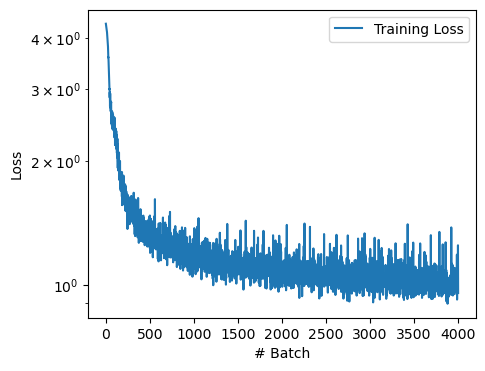

Evaluation Metrics: {'Accuracy': 0.6575164805596664, 'F1-score': 0.6050904511203372}


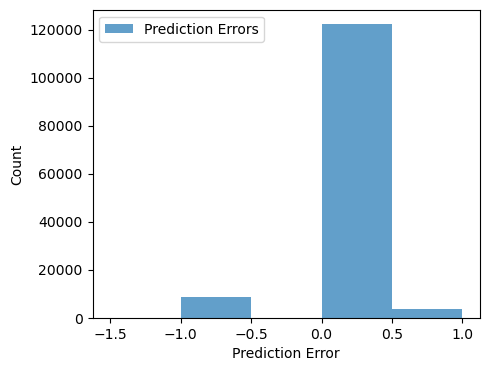

{'Accuracy': 0.6575164805596664, 'F1-score': 0.6050904511203372}

In [1]:
from atoMLtype.RF.GNNmodel import GNNTrainer, BaselineGNN
from atoMLtype.RF.GNNdataset import GNNdataset

# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"

# Initialize dataset and DataLoader
gnn_test_dataset = GNNdataset(sdf_path, json_labels)
num_node_feat = gnn_test_dataset[0].x.shape[1]
num_y_ATs = len(set(gnn_test_dataset.all_labels))
print(f"num_node_features = {num_node_feat}")
print(f"num_y_ATs = {num_y_ATs}")

# Initialize baselineGNN for classification
model = BaselineGNN(num_node_features=num_node_feat, num_atom_types=num_y_ATs)
trainer = GNNTrainer(model, gnn_test_dataset, batch_size=32, learning_rate=0.001, epochs=20, task="classification")

trainer.train()
trainer.evaluate()


# What are the common fingerprints for the different atom types
1. Are the rings something to consider?
2. What about functional group as immediate substituents?
3. 